In [1]:
# Deep Learning for Alzheimer's Detection (FYP Phase 1: Setup & Data Loading)

import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory as IDFD

# --- 0. GPU Configuration (Setup) ---
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ GPU assigned: {gpus[0].name}")
    else:
        print("⚠️ No GPU detected. Falling back to CPU.")
except Exception as e:
    print(f"Error configuring GPU: {e}")


# --- 1. Variables aur Constants Define Karna ---
IMAGE_HEIGHT = 224

IMAGE_WIDTH = 224 
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
BATCH_SIZE = 8
SEED = 42
DATASET_DIR = "/kaggle/input/fyp-dataset/"

print(f"TensorFlow Version: {tf.__version__}")
print(f"Using Image Size: {IMAGE_SIZE} and Batch Size: {BATCH_SIZE}")


# --- 2. Data Pre-processing (Scaling Layer) ---
# Pixel values ko 0-1 range mein laana.
rescaling_layer = Rescaling(1./255)


# --- 3. Data Loading aur Splitting (70:10:20) ---
TRAIN_VAL_SPLIT_RATIO = 0.8 # Train aur Val combined
print("\n--- Loading Training Data (Approx 70%) ---")
train_ds = IDFD(
    DATASET_DIR + "train",
    validation_split=1 - TRAIN_VAL_SPLIT_RATIO, 
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

# --- FIX: Class Names ko turant store kar lena ---
CLASS_NAMES = train_ds.class_names 

print("\n--- Loading Validation Data (Approx 10%) ---")
val_ds = IDFD(
    DATASET_DIR + "train",
    validation_split=1 - TRAIN_VAL_SPLIT_RATIO,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

print("\n--- Loading Test Data (Approx 20%) ---")
test_ds = IDFD(
    DATASET_DIR + "test",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

# --- 4. Rescaling Layer ko Datasets par Apply Karna ---
def apply_rescaling(image, label):
  return rescaling_layer(image), label

train_ds = train_ds.map(apply_rescaling)
val_ds = val_ds.map(apply_rescaling)
test_ds = test_ds.map(apply_rescaling)


# --- 5. Data Size aur Class Information Check Karna ---
print("\n--- Summary of Dataset Split ---")
# Ab hum CLASS_NAMES variable use kar rahe hain
print(f"Class Names (4 stages): {CLASS_NAMES}")

# Data ko memory mein efficient rakhne ke liye prefetch use karna
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("\nCell 1 Complete: Data loaded, split (70:10:20), and preprocessed (Rescaled).")

2026-04-16 05:31:57.731288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776317517.895589      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776317517.956889      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ GPU assigned: /physical_device:GPU:0
TensorFlow Version: 2.18.0
Using Image Size: (224, 224) and Batch Size: 8

--- Loading Training Data (Approx 70%) ---
Found 69148 files belonging to 4 classes.
Using 55319 files for training.


I0000 00:00:1776317599.150314      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



--- Loading Validation Data (Approx 10%) ---
Found 69148 files belonging to 4 classes.
Using 13829 files for validation.

--- Loading Test Data (Approx 20%) ---
Found 17289 files belonging to 4 classes.

--- Summary of Dataset Split ---
Class Names (4 stages): ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Cell 1 Complete: Data loaded, split (70:10:20), and preprocessed (Rescaled).


--- Collecting One Sample from Each of the 4 Classes... ---
Found 69148 files belonging to 4 classes.
Using 55319 files for training.
✅ Success: Collected one sample from all four classes.


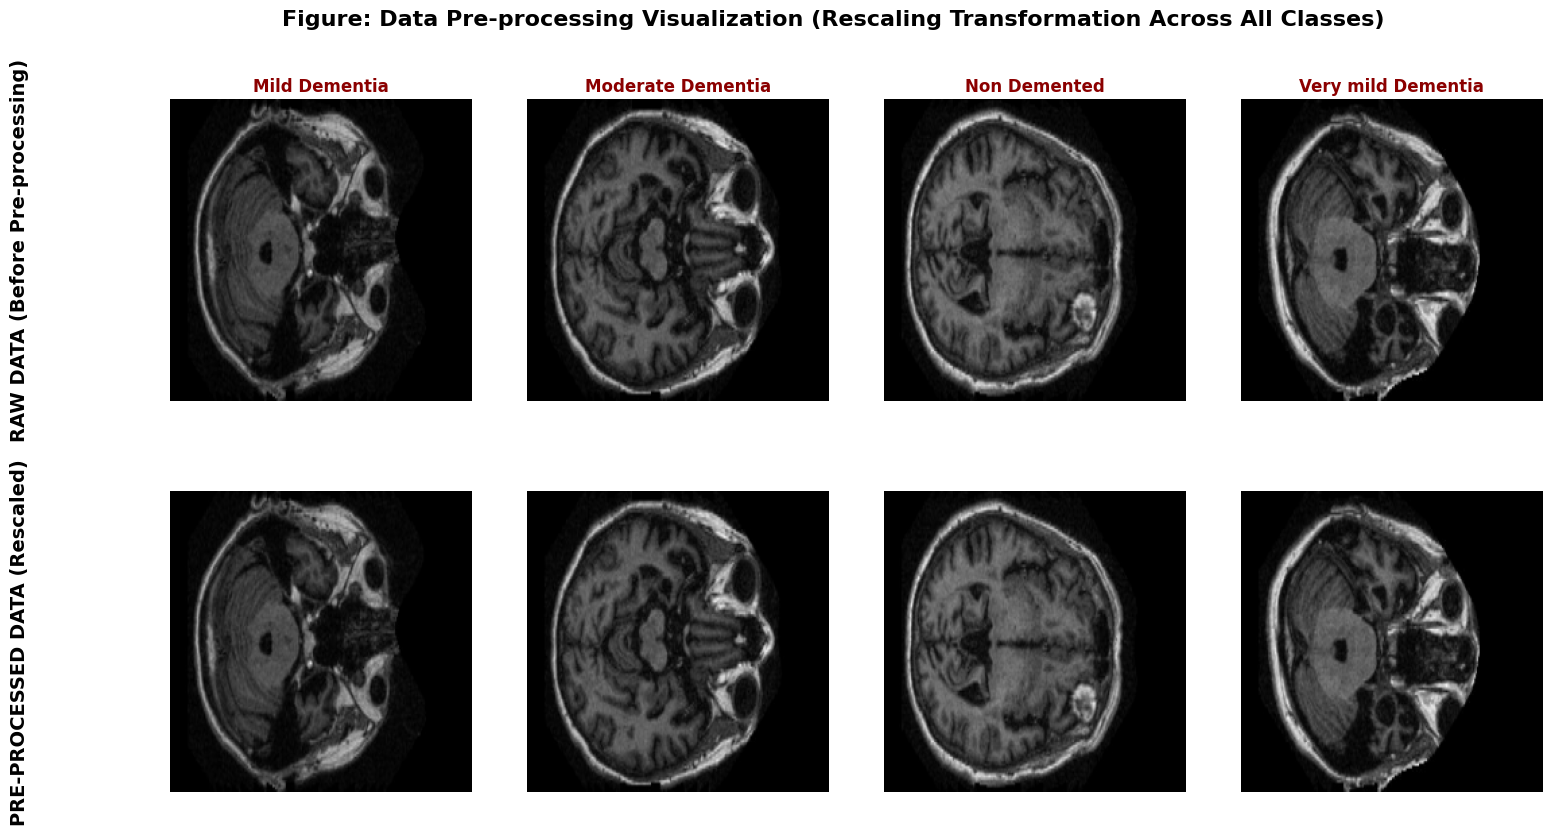


Cell 1.5 Complete: 2x4 visualization generated successfully (Original vs. Rescaled across 4 classes).


In [2]:
# Deep Learning for Alzheimer's Detection (FYP Phase 1.5: 2x4 Grid Visualization)

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# --- 1. Preparation: Collecting One Sample of Each Class ---
print("--- Collecting One Sample from Each of the 4 Classes... ---")

# Step 1: Ek temporary unscaled dataset load karein. 
# Hum seedhe train_ds se unscaled data nahi le sakte kyunki uspar rescaling already apply ho chuki hai.
# Sirf is visualization ke liye, hum dobara data load karenge (without mapping the rescaling layer).
temp_unscaled_ds = IDFD(
    DATASET_DIR + "train",
    validation_split=1 - TRAIN_VAL_SPLIT_RATIO, 
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

# Data structure for collecting one image (unscaled) per class
collected_samples = {} 
target_classes = set(CLASS_NAMES)
max_batches_to_check = 50 

# Dataset ke shuru ke batches ko check karein taa-ke chaaron classes mil jaaen.
for batch_idx, (images, labels) in enumerate(temp_unscaled_ds.take(max_batches_to_check)):
    for i in range(images.shape[0]):
        class_index = np.argmax(labels[i].numpy())
        class_name = CLASS_NAMES[class_index]

        if class_name not in collected_samples:
            # Store the unscaled image (0-255 range)
            collected_samples[class_name] = images[i].numpy() 

        # Agar chaaron classes mil chuki hain toh loop rok do.
        if set(collected_samples.keys()) == target_classes:
            break
    if set(collected_samples.keys()) == target_classes:
        break

if len(collected_samples) != len(CLASS_NAMES):
    print(f"⚠️ Warning: Only {len(collected_samples)} out of {len(CLASS_NAMES)} classes collected after checking {batch_idx+1} batches.")
else:
    print("✅ Success: Collected one sample from all four classes.")

# Sort the collected samples to ensure a consistent order for plotting
sorted_samples = [collected_samples[name] for name in CLASS_NAMES]
sorted_class_names = CLASS_NAMES

# --- 2. 2x4 Grid Plotting ---

fig, axes = plt.subplots(2, 4, figsize=(18, 9)) # 2 rows, 4 columns
plt.subplots_adjust(wspace=0.1, hspace=0.3)

# --- Row 1: Original Images (Unscaled) ---
for i in range(len(sorted_samples)):
    image_unscaled = sorted_samples[i].astype('uint8')
    class_name = sorted_class_names[i]
    
    # Image Plotting
    axes[0, i].imshow(image_unscaled)
    axes[0, i].axis('off')
    
    # Title and Label
    axes[0, i].set_title(class_name, fontsize=12, fontweight='bold', color='darkred')
    axes[0, i].set_xlabel(f"Range: {image_unscaled.min()}-{image_unscaled.max()} (Raw Data)", color='darkred')
    
# Row 1 Master Title
axes[0, 0].text(-0.5, 0.5, 'RAW DATA (Before Pre-processing)', 
                transform=axes[0, 0].transAxes, rotation=90, 
                fontsize=14, va='center', ha='center', fontweight='bold')


# --- Row 2: Pre-processed Images (Rescaled) ---
for i in range(len(sorted_samples)):
    image_unscaled = sorted_samples[i] # Original tensor data
    
    # Apply the rescaling layer defined in Cell 1
    # Note: Hum Rescaling Layer ko seedhe TensorFlow tensor par apply kar rahe hain.
    image_rescaled = rescaling_layer(tf.expand_dims(image_unscaled, 0))[0].numpy()
    
    # Image Plotting
    axes[1, i].imshow(image_rescaled)
    axes[1, i].axis('off')
    
    # Label (Numerical difference is visible here)
    axes[1, i].set_xlabel(f"Range: {image_rescaled.min():.4f}-{image_rescaled.max():.4f} (Scaled 0-1)", color='darkblue')

# Row 2 Master Title
axes[1, 0].text(-0.5, 0.5, 'PRE-PROCESSED DATA (Rescaled)', 
                transform=axes[1, 0].transAxes, rotation=90, 
                fontsize=14, va='center', ha='center', fontweight='bold')


# Main Title
plt.suptitle("Figure: Data Pre-processing Visualization (Rescaling Transformation Across All Classes)", 
             fontsize=16, fontweight='bold') 

plt.show()

print("\nCell 1.5 Complete: 2x4 visualization generated successfully (Original vs. Rescaled across 4 classes).")

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomRotation, RandomTranslation, RandomZoom

data_augmentation = Sequential([
    RandomRotation(factor=0.02, seed=42), 
    RandomTranslation(height_factor=0.05, width_factor=0.05, seed=42), 
    RandomZoom(height_factor=0.05, width_factor=0.05, seed=42),
], name="data_augmentation")

print("✅ Data Augmentation Layers Defined.")
print("Yeh layer ab har model ke shuru mein use hogi.")

print("\nCell 2 Complete: Data Augmentation successfully defined.")

✅ Data Augmentation Layers Defined.
Yeh layer ab har model ke shuru mein use hogi.

Cell 2 Complete: Data Augmentation successfully defined.


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# --- DEMO Layer (Aggressive Transformations for Figure) ---
# We use aggressive factors here to make the transformation clearly visible.
demo_augmentation = tf.keras.Sequential([
    # Increased rotation factor
    tf.keras.layers.RandomRotation(factor=0.25, seed=42), 
    # Increased height and width shift factor
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2, seed=42), 
    # Increased zoom factor
    tf.keras.layers.RandomZoom(height_factor=(0.1, 0.3), seed=42), 
    # Increased contrast factor
    tf.keras.layers.RandomContrast(factor=0.2, seed=42), 
])

# 1. Select ONE batch of images from the training dataset
# train_ds should be loaded from Cell 1
for images, labels in train_ds.take(1):
    # Select the very first image in that batch (index 0)
    original_image = images[0]
    break # Stop after getting the first image

# 2. Define the plotting configuration
NUM_EXAMPLES = 5 
fig, axes = plt.subplots(1, NUM_EXAMPLES, figsize=(18, 6)) # 1 row, 5 columns

# 3. Plot the Original Image
axes[0].imshow(original_image.numpy(), cmap='gray') # Use 'gray' colormap
axes[0].set_title("Original Input Image") # Title in English
axes[0].axis('off')

# 4. Generate and Plot Augmented Versions
for i in range(1, NUM_EXAMPLES):
    # Apply the 'demo_augmentation' layer
    augmented_image = demo_augmentation(tf.expand_dims(original_image, 0)) 
    
    # Plot the result (remove batch dimension: [0])
    axes[i].imshow(augmented_image[0].numpy(), cmap='gray')
    
    # Describe the transformation in English
    if i == 1:
        title = "Rotated and Shifted"
    elif i == 2:
        title = "Zoomed and Contrast"
    elif i == 3:
        title = "Shifted and Rotated"
    else:
        title = "Combined Augmentation"
        
    axes[i].set_title(title)
    axes[i].axis('off')

# Main title in English
plt.suptitle("Demonstration of Data Augmentation Transformations", fontsize=18) 
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Is plot ka high-resolution screenshot lein aur report mein Figure 4.x ke taur par use karein.

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D

IMAGE_SIZE = (224, 224)
NUM_CLASSES = len(CLASS_NAMES)

inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))

x = data_augmentation(inputs)

x = Conv2D(32, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_cnn = tf.keras.Model(inputs=inputs, outputs=outputs, name="Custom_CNN_Light")

model_cnn.compile(
    optimizer=Adamax(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

model_cnn.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
EPOCHS = 10

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

In [ ]:
test_results = model_cnn.evaluate(test_ds)

for name, value in zip(model_cnn.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

In [ ]:
model_cnn.save("final_cnn_model.keras")
print("Model saved")

In [ ]:
cnn_results = model_cnn.evaluate(test_ds, verbose=0)
print("CNN Results:", cnn_results)

In [ ]:
import json

cnn_dict = {
    "loss": float(cnn_results[0]),
    "accuracy": float(cnn_results[1]),
    "precision": float(cnn_results[2]),
    "recall": float(cnn_results[3]),
    "auc": float(cnn_results[4])
}

with open("cnn_results.json", "w") as f:
    json.dump(cnn_dict, f)

print("Saved cnn_results.json")

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["Custom CNN"],
    "Loss": [cnn_results[0]],
    "Accuracy": [cnn_results[1]],
    "Precision": [cnn_results[2]],
    "Recall": [cnn_results[3]],
    "AUC": [cnn_results[4]]
})

df.to_csv("cnn_results.csv", index=False)

print(df)

In [ ]:
import pickle

with open("cnn_history.pkl", "wb") as f:
    pickle.dump(history_cnn.history, f)

print("Saved cnn_history.pkl")

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.applications import DenseNet201

# --- Variables ---
IMAGE_SIZE = (224, 224)
NUM_CLASSES = len(CLASS_NAMES)

# --- DenseNet201 Base Model ---
base_model_densenet = DenseNet201(
    include_top=False,
    weights="imagenet",
    input_shape=IMAGE_SIZE + (3,),
    pooling='max'
)

# Freeze base model for first training phase
base_model_densenet.trainable = False

# --- Final Model ---
model_densenet = Sequential([
    data_augmentation,
    base_model_densenet,
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name="DenseNet201_Model")

# --- Compile ---
model_densenet.compile(
    optimizer=Adamax(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

print("\n--- DenseNet201 Model Summary ---")
model_densenet.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- DenseNet201 Model Summary ---


Model: "DenseNet201_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 1920)           │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,321,984 (69.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,321,984 (69.89 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_densenet = ModelCheckpoint(
    "best_densenet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [6]:
history_densenet = model_densenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint_densenet, reduce_lr]
)

Epoch 1/10


I0000 00:00:1776317763.351582     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


6915/6915 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7010 - auc: 0.8734 - loss: 1.1638 - precision: 0.7101 - recall: 0.6837
Epoch 1: val_accuracy improved from -inf to 0.78017, saving model to best_densenet_model.keras
6915/6915 ━━━━━━━━━━━━━━━━━━━━ 573s 78ms/step - accuracy: 0.7010 - auc: 0.8734 - loss: 1.1638 - precision: 0.7101 - recall: 0.6837 - val_accuracy: 0.7802 - val_auc: 0.9453 - val_loss: 0.6822 - val_precision: 0.8679 - val_recall: 0.6596 - learning_rate: 1.0000e-04
Epoch 2/10
6915/6915 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7696 - auc: 0.9268 - loss: 0.6498 - precision: 0.7884 - recall: 0.7415
Epoch 2: val_accuracy improved from 0.78017 to 0.78249, saving model to best_densenet_model.keras
6915/6915 ━━━━━━━━━━━━━━━━━━━━ 528s 76ms/step - accuracy: 0.7696 - auc: 0.9268 - loss: 0.6498 - precision: 0.7884 - recall: 0.7415 - val_accuracy: 0.7825 - val_auc: 0.9532 - val_loss: 0.6210 - val_precision: 0.8854 - val_recall: 0.6763 - learning_rate: 1.0000e-04
Epoch 3/10

In [7]:
densenet_results = model_densenet.evaluate(test_ds, verbose=0)
print("DenseNet201 Results:", densenet_results)

DenseNet201 Results: [0.5388004183769226, 0.8031117916107178, 0.9295313358306885, 0.6401180028915405, 0.962451159954071]


In [8]:
model_densenet.save("final_densenet_model.keras")
print("DenseNet model saved")

DenseNet model saved


In [ ]:
import pandas as pd

df_densenet = pd.DataFrame({
    "Model": ["DenseNet201"],
    "Loss": [densenet_results[0]],
    "Accuracy": [densenet_results[1]],
    "Precision": [densenet_results[2]],
    "Recall": [densenet_results[3]],
    "AUC": [densenet_results[4]]
})

df_densenet.to_csv("densenet_results.csv", index=False)
print(df_densenet)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.applications import MobileNetV2

IMAGE_SIZE = (224, 224)
NUM_CLASSES = len(CLASS_NAMES)

base_model_mobilenet = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=IMAGE_SIZE + (3,),
    pooling="max"
)

# First phase: freeze base model
base_model_mobilenet.trainable = False

model_mobilenet = Sequential([
    data_augmentation,
    base_model_mobilenet,
    Dropout(0.4),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="MobileNetV2_Model")

model_mobilenet.compile(
    optimizer=Adamax(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

model_mobilenet.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_mobilenet = ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint_mobilenet, reduce_lr]
)

In [ ]:
base_model_mobilenet.trainable = True

for layer in base_model_mobilenet.layers[:-20]:
    layer.trainable = Falsefine_history = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint_mobilenet, reduce_lr]
)

In [ ]:
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
fine_history = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint_mobilenet, reduce_lr]
)

In [ ]:
mobilenet_results = model_mobilenet.evaluate(test_ds, verbose=0)
print("MobileNet Results:", mobilenet_results)

In [ ]:
model_mobilenet.save("final_mobilenet_model.keras")

In [ ]:
import pandas as pd

df_mobilenet = pd.DataFrame({
    "Model": ["MobileNetV2"],
    "Loss": [mobilenet_results[0]],
    "Accuracy": [mobilenet_results[1]],
    "Precision": [mobilenet_results[2]],
    "Recall": [mobilenet_results[3]],
    "AUC": [mobilenet_results[4]]
})

df_mobilenet.to_csv("mobilenet_results.csv", index=False)

print(df_mobilenet)

In [ ]:
import tensorflow as tf

model_mobilenet = tf.keras.models.load_model(
    "/kaggle/working/best_mobilenet_model.keras"
)

print("Model loaded")

In [ ]:
CLASS_NAMES = [
    "Mild Dementia",
    "Moderate Dementia",
    "Non Demented",
    "Very mild Dementia"
]

In [ ]:
base_model_mobilenet = model_mobilenet.layers[1]

In [ ]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dropout, Dense

NUM_CLASSES = len(CLASS_NAMES)

inputs = Input(shape=(224, 224, 3))

x = base_model_mobilenet(inputs, training=False)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

mobilenet_inference_model = Model(inputs, outputs)

In [ ]:
mobilenet_inference_model.layers[1].set_weights(model_mobilenet.layers[1].get_weights())
mobilenet_inference_model.layers[3].set_weights(model_mobilenet.layers[3].get_weights())
mobilenet_inference_model.layers[5].set_weights(model_mobilenet.layers[5].get_weights())

In [ ]:
mobilenet_inference_model.save("mobilenet_inference.keras")
print("Saved mobilenet_inference.keras")

In [ ]:
import json

with open("labels.json", "w") as f:
    json.dump(CLASS_NAMES, f)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.applications import ResNet50

IMAGE_SIZE = (224, 224)
NUM_CLASSES = len(CLASS_NAMES)

base_model_resnet = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=IMAGE_SIZE + (3,),
    pooling='max'
)

# Freeze base model
base_model_resnet.trainable = False

model_resnet = Sequential([
    data_augmentation,
    base_model_resnet,
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name="ResNet50_Model")

model_resnet.compile(
    optimizer=Adamax(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

model_resnet.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_resnet = ModelCheckpoint(
    "best_resnet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint_resnet, reduce_lr]
)

In [ ]:
base_model_resnet.trainable = True

for layer in base_model_resnet.layers[:-20]:
    layer.trainable = False

In [ ]:
model_resnet.compile(
    optimizer=Adamax(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [ ]:
fine_history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint_resnet, reduce_lr]
)

In [ ]:
resnet_results = model_resnet.evaluate(test_ds, verbose=0)
print("ResNet50 Results:", resnet_results)

In [ ]:
model_resnet.save("final_resnet_model.keras")
print("ResNet model saved")

In [ ]:
import pandas as pd

df_resnet = pd.DataFrame({
    "Model": ["ResNet50"],
    "Loss": [resnet_results[0]],
    "Accuracy": [resnet_results[1]],
    "Precision": [resnet_results[2]],
    "Recall": [resnet_results[3]],
    "AUC": [resnet_results[4]]
})

df_resnet.to_csv("resnet_results.csv", index=False)

print(df_resnet)

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "DenseNet201", "MobileNetV2", "ResNet50"],
    "Loss": [cnn_results[0], densenet_results[0], mobilenet_results[0], resnet_results[0]],
    "Accuracy": [cnn_results[1], densenet_results[1], mobilenet_results[1], resnet_results[1]],
    "Precision": [cnn_results[2], densenet_results[2], mobilenet_results[2], resnet_results[2]],
    "Recall": [cnn_results[3], densenet_results[3], mobilenet_results[3], resnet_results[3]],
    "AUC": [cnn_results[4], densenet_results[4], mobilenet_results[4], resnet_results[4]],
})

print(comparison_df.sort_values(by="Accuracy", ascending=False))

In [ ]:
import pandas as pd

cnn_df = pd.read_csv("/kaggle/working/cnn_results.csv")
densenet_df = pd.read_csv("/kaggle/working/densenet_results.csv")
mobilenet_df = pd.read_csv("/kaggle/working/mobilenet_results.csv")
resnet_df = pd.read_csv("/kaggle/working/resnet_results.csv")

print(cnn_df)
print(densenet_df)
print(mobilenet_df)
print(resnet_df)

In [ ]:
comparison_df = pd.concat(
    [cnn_df, densenet_df, mobilenet_df, resnet_df],
    ignore_index=True
)

print(comparison_df)

In [ ]:
comparison_sorted = comparison_df.sort_values(by="Accuracy", ascending=False)
print(comparison_sorted)

In [ ]:
comparison_sorted.to_csv("/kaggle/working/model_comparison.csv", index=False)
print("Saved model_comparison.csv")

In [ ]:
import json

class_names = CLASS_NAMES

with open("labels.json", "w") as f:
    json.dump(class_names, f)

print("labels.json saved")

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["DenseNet201", "MobileNetV2", "ResNet50", "Custom CNN"],
    "Loss": [0.537446, 0.517785, 0.508240, 0.676367],
    "Accuracy": [0.805715, 0.801839, 0.794436, 0.777662],
    "Precision": [0.924855, 0.928252, 0.885821, 0.777752],
    "Recall": [0.636416, 0.636821, 0.673550, 0.777662],
    "AUC": [0.962198, 0.961067, 0.956508, 0.923109]
})

comparison_df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Accuracy Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["Loss"])
plt.title("Loss Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Loss")
plt.xticks(rotation=15)
plt.show()


In [ ]:
plt.figure(figsize=(10,6))

plt.plot(comparison_df["Model"], comparison_df["Precision"], marker='o', label="Precision")
plt.plot(comparison_df["Model"], comparison_df["Recall"], marker='o', label="Recall")
plt.plot(comparison_df["Model"], comparison_df["AUC"], marker='o', label="AUC")
plt.plot(comparison_df["Model"], comparison_df["Accuracy"], marker='o', label="Accuracy")

plt.title("Performance Metrics Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import os

base_path = "/kaggle/input/models/muhammadwaleedgc/models/keras/1/1"

for file in os.listdir(base_path):
    print(file)

final_densenet_model.keras
final_mobilenet_model.keras
final_resnet_model.keras
final_cnn_model.keras


In [10]:
import tensorflow as tf

base_path = "/kaggle/input/models/muhammadwaleedgc/models/keras/1/1"

models = {
    "Custom CNN": tf.keras.models.load_model(f"{base_path}/final_cnn_model.keras"),
    "MobileNetV2": tf.keras.models.load_model(f"{base_path}/final_mobilenet_model.keras"),
    "DenseNet201": tf.keras.models.load_model(f"{base_path}/final_densenet_model.keras"),
    "ResNet50": tf.keras.models.load_model(f"{base_path}/final_resnet_model.keras"),
}

In [11]:
y_true = []

for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

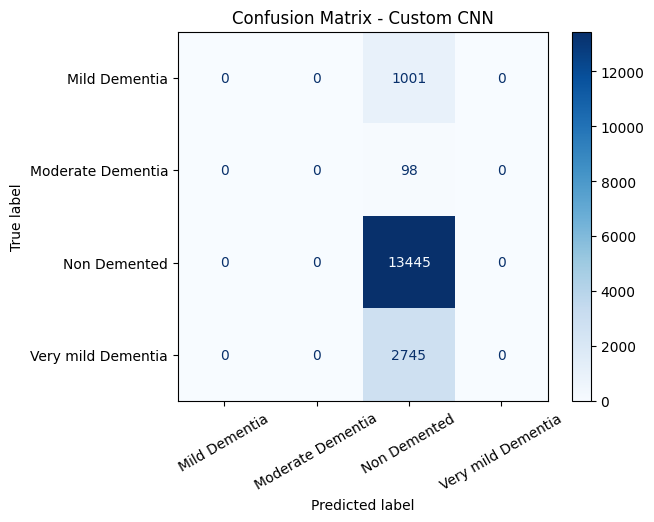

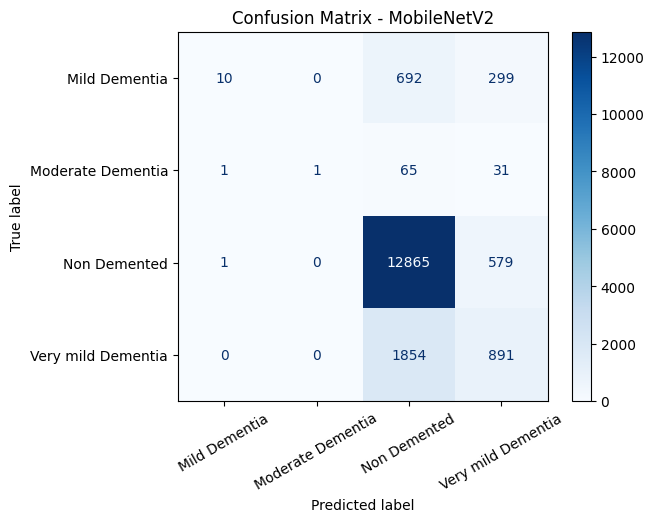

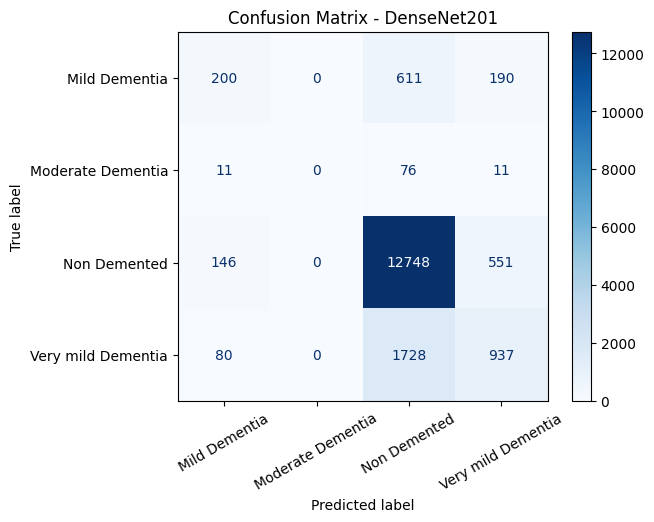

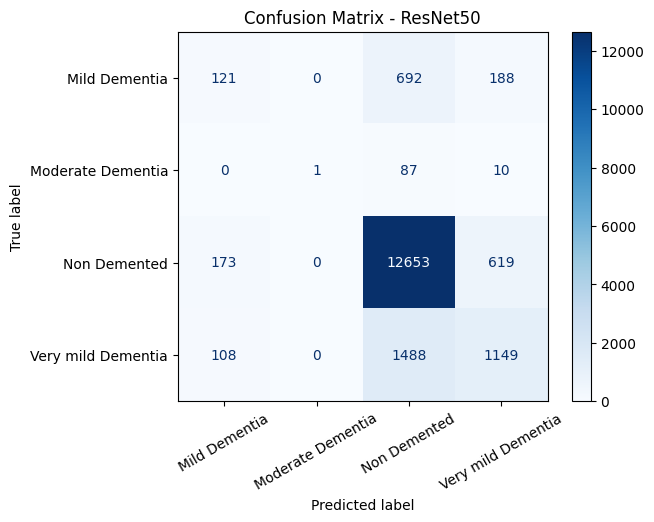

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for model_name, model in models.items():
    y_pred = []

    for images, _ in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", xticks_rotation=30)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [19]:
y_true = []

for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

NUM_CLASSES = len(CLASS_NAMES)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

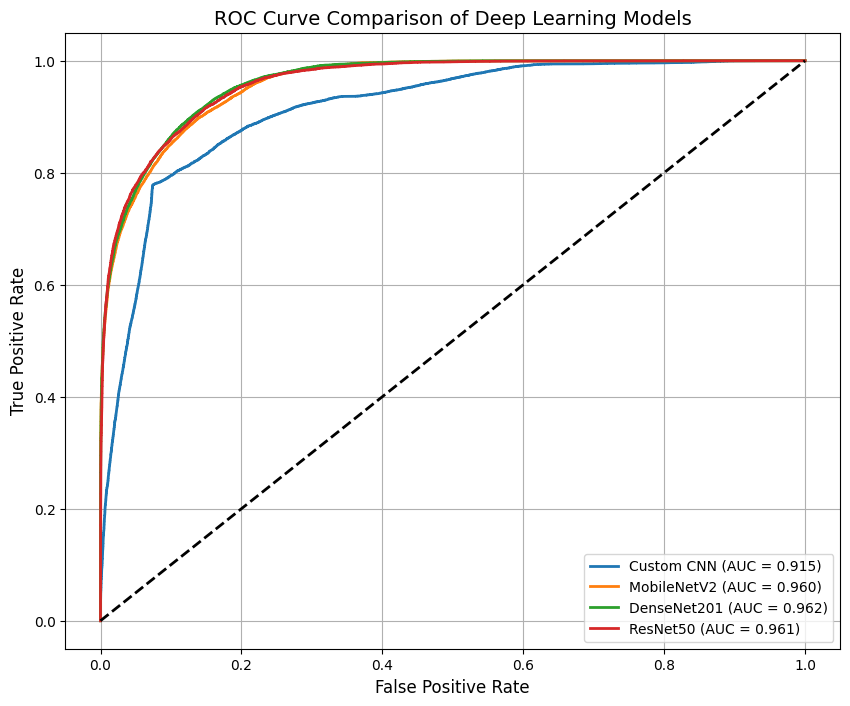

In [20]:
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    y_scores = []

    for images, _ in test_ds:
        preds = model.predict(images, verbose=0)
        y_scores.extend(preds)

    y_scores = np.array(y_scores)

    # Micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2,
             label=f"{model_name} (AUC = {roc_auc:.3f})")

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

plt.title("ROC Curve Comparison of Deep Learning Models", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    y_scores = []

    for images, _ in test_ds:
        preds = model.predict(images, verbose=0)
        y_scores.extend(preds)

    y_scores = np.array(y_scores)

    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2,
             label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.title("ROC Curve Comparison of Deep Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig("/kaggle/working/roc_curve_comparison.png", dpi=300)
plt.show()